# GBD_13 — Closed-loop LiDAR with planar mirror target (Era 3, step 2)

**The first notebook to close the LiDAR loop.** Source → TX lens → mirror at R=100m → return → RX aperture → receive plane.

**Three things new vs. GBD_12:**
1. **Mirror reflection** with reflectivity ρ. By the image method (planar mirror at normal incidence), round-trip propagation is equivalent to forward propagation by 2R in unfolded coordinates.
2. **Re-decomposition** of the truncated return field into a receive-side basis. First time we exercise the LSQ-at-aperture machinery from CONCEPTS Topic 7.
3. **The 81-beamlet basis comes back** (after GBD_12's single-beam interlude). And this time we use **two bases** — one matched to the source, one matched to the receive plane.

**Why two bases?** The source is 1 mm wide (well-fit by the GBD_11 v2 source basis: w=1mm, spacing 1.5mm, ±6mm). After the round trip the beam expands to ~221 mm, then the RX aperture clips it down to 25 mm. The truncated return is 25 mm wide — too big for the source basis (which only spans ±6 mm). We need a receive basis matched to the RX aperture extent: w_rx=2.5mm, spacing 4mm, ±16mm. This is the standard pattern in GBD pipelines: each plane has its own basis sized to the local beam size.

**Geometry parameters (locked in):**
- λ = 1550 nm, source w₀ = 1 mm.
- TX aperture D = 10 mm at z = 0+ (negligible truncation, ignored in the chain — see CONCEPTS Topic 7 for the sizing argument).
- TX lens f = 1 m at z = 0+.
- Mirror at z = R = 100 m. Reflectivity ρ ∈ {1.0, 0.1}.
- RX aperture D = 25 mm at receive plane (unfolded z = 2R = 200 m).
- Co-axial: TX and RX share the optical axis.

**Predictions:**
- After lens at z=0+: q' = −0.804 − 0.397i. New (focused) waist at z = 0.804 m, w = 0.442 mm.
- At mirror z=R: w = 110 mm.
- At receive plane z=2R: w = 221 mm.
- Power transmission through 25 mm RX aperture: T = 1 − exp(−2·(12.5/221)²) = **0.64%** for ρ=1; **0.064%** for ρ=0.1.
- Source basis decomposition floor: ~10⁻⁹ (carry from GBD_11 v2).
- Receive basis decomposition floor of truncated field: **~10⁻¹** (sharp aperture edge fundamentally limits how well smooth Gaussians can fit a step function — the basis can fit the inside, but the abrupt cut at r=D/2 is unrepresentable). Finer basis would improve this but at quadratic memory cost.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- LiDAR / Era 3 parameters ---
wavelength = 1550e-9
w0_source  = 1.0e-3
k          = 2*np.pi / wavelength
zR_source  = np.pi * w0_source**2 / wavelength

D_TX = 10e-3
D_RX = 25e-3
f_lens = 1.0
z_lens = 0.0
R_target = 100.0
z_receive_unfolded = 2 * R_target    # image method: receive plane = z = 2R in unfolded coords

# --- Source basis (carry from GBD_11 v2) ---
n_per_axis = 9
spacing_source = 1.5e-3
w_basis_source = 1.0e-3
x0_grid_source = (np.arange(n_per_axis) - (n_per_axis-1)/2) * spacing_source

# --- Receive basis (NEW, matched to RX aperture extent) ---
spacing_receive = 4.0e-3
w_basis_receive = 2.5e-3
x0_grid_receive = (np.arange(n_per_axis) - (n_per_axis-1)/2) * spacing_receive

lambda_reg = 1e-8

print(f'Wavelength       = {wavelength*1e9:.1f} nm')
print(f'Source w0        = {w0_source*1e3:.3f} mm')
print(f'zR_source        = {zR_source:.4f} m')
print(f'\nSource basis: w = {w_basis_source*1e3:.3f} mm, spacing = {spacing_source*1e3:.2f} mm, ±{(n_per_axis-1)/2*spacing_source*1e3:.1f} mm extent')
print(f'Receive basis: w = {w_basis_receive*1e3:.3f} mm, spacing = {spacing_receive*1e3:.2f} mm, ±{(n_per_axis-1)/2*spacing_receive*1e3:.1f} mm extent')
print(f'\nOptical chain:')
print(f'  TX aperture D={D_TX*1e3:.1f}mm (ignored: negligible)')
print(f'  TX lens f={f_lens:.2f}m at z={z_lens}')
print(f'  Mirror at z = R = {R_target} m')
print(f'  RX aperture D={D_RX*1e3:.1f}mm at receive plane (unfolded z = 2R = {z_receive_unfolded} m)')

Wavelength       = 1550.0 nm
Source w0        = 1.000 mm
zR_source        = 2.0268 m

Source basis: w = 1.000 mm, spacing = 1.50 mm, ±6.0 mm extent
Receive basis: w = 2.500 mm, spacing = 4.00 mm, ±16.0 mm extent

Optical chain:
  TX aperture D=10.0mm (ignored: negligible)
  TX lens f=1.00m at z=0.0
  Mirror at z = R = 100.0 m
  RX aperture D=25.0mm at receive plane (unfolded z = 2R = 200.0 m)


In [2]:
# --- Two grids ---
# LSQ grid: small, fine. For decompositions (source at z=0, receive plane at z=2R).
Nx_lsq = Ny_lsq = 401
Lx_lsq = Ly_lsq = 20e-3                     # ±20 mm
x_lsq = np.linspace(-Lx_lsq, Lx_lsq, Nx_lsq)
y_lsq = np.linspace(-Ly_lsq, Ly_lsq, Ny_lsq)
X_lsq, Y_lsq = np.meshgrid(x_lsq, y_lsq, indexing='xy')
dx_lsq = x_lsq[1] - x_lsq[0]

# Visualization grid: large, modest. For displaying beams at intermediate planes.
Nx = Ny = 2049
Lx = Ly = 400e-3                             # ±400 mm — need wide grid for full beam at receive plane (w=222mm)
x = np.linspace(-Lx, Lx, Nx)
y = np.linspace(-Ly, Ly, Ny)
X, Y = np.meshgrid(x, y, indexing='xy')
dx = x[1] - x[0]

print(f'LSQ grid:           {Nx_lsq}x{Ny_lsq}, ±{Lx_lsq*1e3:.0f}mm, dx = {dx_lsq*1e6:.0f} µm')
print(f'  samples per source w0     = {w0_source/dx_lsq:.2f}')
print(f'  samples per source basis w= {w_basis_source/dx_lsq:.2f}')
print(f'  samples per recv basis w  = {w_basis_receive/dx_lsq:.2f}')
print(f'\nViz grid:           {Nx}x{Ny}, ±{Lx*1e3:.0f}mm, dx = {dx*1e6:.0f} µm')
print(f'  samples per source w0     = {w0_source/dx:.2f}')

LSQ grid:           401x401, ±20mm, dx = 100 µm
  samples per source w0     = 10.00
  samples per source basis w= 10.00
  samples per recv basis w  = 25.00

Viz grid:           2049x2049, ±400mm, dx = 391 µm
  samples per source w0     = 2.56


## State representation and propagator (carried from GBD_12)

Each beamlet carries a `state` dict with `(q_anchor, z_anchor, x_anchor, y_anchor, kx, ky)`. The propagator evaluates the field at any z analytically. See CONCEPTS Topic 6 for derivation.

In [3]:
def make_source_state(w0, k, x0=0.0, y0=0.0, kx=0.0, ky=0.0, z0=0.0):
    wl = 2*np.pi/k
    zR = np.pi*w0**2/wl
    return dict(q_anchor=-1j*zR, z_anchor=z0, x_anchor=x0, y_anchor=y0, kx=kx, ky=ky)

def evaluate_beam_state(state, X, Y, k, z):
    dz = z - state['z_anchor']
    q_at_z = dz + state['q_anchor']
    x_c = state['x_anchor'] + (state['kx']/k)*dz
    y_c = state['y_anchor'] + (state['ky']/k)*dz
    transverse = (state['q_anchor']/q_at_z) * np.exp(1j*k*((X-x_c)**2+(Y-y_c)**2)/(2*q_at_z))
    kz = np.sqrt(k**2 - state['kx']**2 - state['ky']**2)
    longitudinal = np.exp(1j*kz*dz)
    tilt = np.exp(1j*(state['kx']*X + state['ky']*Y))
    return transverse*longitudinal*tilt

def apply_thin_lens(state, f, z_lens, k):
    """Per-beamlet lens transformation: q-update + kx/ky redirection toward focal point."""
    dz = z_lens - state['z_anchor']
    q_at_lens = dz + state['q_anchor']
    x_at_lens = state['x_anchor'] + (state['kx']/k)*dz
    y_at_lens = state['y_anchor'] + (state['ky']/k)*dz
    one_over_q_after = 1.0/q_at_lens - 1.0/f
    q_after = 1.0/one_over_q_after
    kx_new = state['kx'] - k*x_at_lens/f
    ky_new = state['ky'] - k*y_at_lens/f
    return dict(q_anchor=q_after, z_anchor=z_lens, x_anchor=x_at_lens, y_anchor=y_at_lens, kx=kx_new, ky=ky_new)

def apply_circular_aperture(E, X, Y, D):
    R2 = X**2 + Y**2
    return E * (R2 < (D/2)**2).astype(float)

def basis_sum_at_z(basis_states, coefficients, X, Y, k, z):
    """Sum the basis weighted by coefficients at a given z, on a (X, Y) grid."""
    E = np.zeros_like(X, dtype=complex)
    for state, c in zip(basis_states, coefficients):
        E += c * evaluate_beam_state(state, X, Y, k, z=z)
    return E

## Build source basis and decompose source

Source basis: 9×9 = 81 Gaussians at width 1 mm, spaced 1.5 mm, on the source plane. LSQ on the small (±20 mm) grid where the source is well-localized.

In [4]:
# Build source basis state list
basis_states_source = []
for x0i in x0_grid_source:
    for y0i in x0_grid_source:
        basis_states_source.append(make_source_state(w_basis_source, k, x0=x0i, y0=y0i, z0=0.0))
N_beams = len(basis_states_source)

# Build G matrix on the small LSQ grid (≈200 MB)
t0 = time.time()
G_source = np.zeros((Nx_lsq*Ny_lsq, N_beams), dtype=complex)
for i, state in enumerate(basis_states_source):
    G_source[:, i] = evaluate_beam_state(state, X_lsq, Y_lsq, k, z=0.0).ravel()
print(f'Built G_source in {time.time()-t0:.2f} s, size {G_source.nbytes/1e6:.0f} MB')

# Source field on LSQ grid (1 mm Gaussian centered at origin)
E_source_lsq = np.exp(-(X_lsq**2 + Y_lsq**2)/w0_source**2).astype(complex)

# LSQ solve
t0 = time.time()
GhG = G_source.conj().T @ G_source
Ghe = G_source.conj().T @ E_source_lsq.ravel()
A = GhG + lambda_reg * np.eye(N_beams)
c_source = np.linalg.solve(A, Ghe)
print(f'Solved source LSQ in {(time.time()-t0)*1e3:.0f} ms')

# Decomposition floor at z=0
E_recon_source = (G_source @ c_source).reshape(Ny_lsq, Nx_lsq)
L2_source_floor = np.linalg.norm(E_recon_source - E_source_lsq) / np.linalg.norm(E_source_lsq)
print(f'\n[Sanity 1] Source basis decomposition L2 rel at z=0: {L2_source_floor:.3e}')
print(f'(Expected ~10⁻⁹ from GBD_11 v2)')

Built G_source in 0.60 s, size 208 MB
Solved source LSQ in 1869 ms

[Sanity 1] Source basis decomposition L2 rel at z=0: 8.268e-11
(Expected ~10⁻⁹ from GBD_11 v2)


## Apply lens to each basis beamlet (per-beamlet q-update + kx/ky redirect)

Each of the 81 beamlets gets the same q-transformation (since they all share q_anchor at z=0), but each gets its own kx/ky redirection toward the focal point — proportional to its position offset from the optical axis. See CONCEPTS Topic 6 for the math.

In [5]:
basis_states_postlens = [apply_thin_lens(state, f=f_lens, z_lens=z_lens, k=k) 
                          for state in basis_states_source]

# Inspect: central beamlet (was at origin, kx=ky=0) and a corner beamlet (was at (6mm, 6mm))
print('Central beamlet, post-lens:')
s = basis_states_postlens[40]   # central index in 9x9 = 40
print(f'  q_anchor = {s["q_anchor"]:+.4f}, kx = {s["kx"]:+.1f}, ky = {s["ky"]:+.1f}')
print(f'  (kx_new = -k·x_anchor/f = -k·0/1 = 0 — no redirect because central beamlet was on-axis)')

print('\nCorner beamlet (originally at (+6mm, +6mm)), post-lens:')
s = basis_states_postlens[80]   # last index in 9x9 = 80, corresponds to (6mm, 6mm)
expected_kx = -k * 6e-3 / f_lens
print(f'  q_anchor = {s["q_anchor"]:+.4f}, kx = {s["kx"]:+.1f}, ky = {s["ky"]:+.1f}')
print(f'  Expected kx = -k·6e-3/1 = {expected_kx:+.1f} ✓')
print(f'  Equivalent angle = {s["kx"]/k*1e3:+.3f} mrad (toward optical axis)')

Central beamlet, post-lens:
  q_anchor = -0.8042-0.3968j, kx = +0.0, ky = +0.0
  (kx_new = -k·x_anchor/f = -k·0/1 = 0 — no redirect because central beamlet was on-axis)

Corner beamlet (originally at (+6mm, +6mm)), post-lens:
  q_anchor = -0.8042-0.3968j, kx = -24322.0, ky = -24322.0
  Expected kx = -k·6e-3/1 = -24322.0 ✓
  Equivalent angle = -6.000 mrad (toward optical axis)


## Sanity: basis sum at z=0+ (post-lens) matches single-Gaussian post-lens

Since the basis decomposes the source (with L2 rel ≈ 10⁻⁹), and the lens transformation is linear, the basis sum after the lens should equal the source × lens-phase, also to L2 rel ≈ 10⁻⁹.

This validates that per-beamlet lens application is correct on the basis level.

In [6]:
# Basis sum post-lens at z=0+ (LSQ grid)
E_basis_postlens_lsq = basis_sum_at_z(basis_states_postlens, c_source, X_lsq, Y_lsq, k, z=z_lens)

# Direct: source × lens-phase
lens_phase_lsq = np.exp(-1j*k*(X_lsq**2 + Y_lsq**2)/(2*f_lens))
E_postlens_direct_lsq = E_source_lsq * lens_phase_lsq

L2_postlens = np.linalg.norm(E_basis_postlens_lsq - E_postlens_direct_lsq) / np.linalg.norm(E_postlens_direct_lsq)
print(f'[Sanity 2] Basis sum post-lens vs source*lens_phase at z=0+: L2 rel = {L2_postlens:.3e}')
print(f'(Expected ≈ source decomposition floor {L2_source_floor:.3e} — confirms per-beamlet lens math is correct)')

[Sanity 2] Basis sum post-lens vs source*lens_phase at z=0+: L2 rel = 1.444e-10
(Expected ≈ source decomposition floor 8.268e-11 — confirms per-beamlet lens math is correct)


## Round-trip propagation via image method

For a planar mirror at z = R with normal incidence: the round-trip from z=0 to mirror to z=0 is **equivalent to forward propagation by 2R in unfolded coordinates**. The receive plane at real z=0 corresponds to unfolded z=2R.

This avoids the bookkeeping of "forward then backward propagation" — we just propagate forward by 2R.

In [7]:
# Compute basis sum at the receive plane (unfolded z=2R)
t0 = time.time()
E_at_receive_lsq = basis_sum_at_z(basis_states_postlens, c_source, X_lsq, Y_lsq, k, z=z_receive_unfolded)
print(f'basis_sum_at_z to receive plane took {time.time()-t0:.2f} s')

# Predicted central amplitude — the centered focused/expanded beam at z=2R has w(2R) ≈ 221 mm
# Peak amplitude at center: |q_post_lens / q_at_2R|
q_post_lens = basis_states_postlens[40]['q_anchor']
q_at_receive = z_receive_unfolded + q_post_lens
peak_amp_predicted = np.abs(q_post_lens / q_at_receive)
w_at_receive = np.sqrt(wavelength / (np.pi * (1/q_at_receive).imag))
print(f'\nAt receive plane (unfolded z=2R={z_receive_unfolded}m):')
print(f'  Predicted peak amplitude (single-Gaussian) = {peak_amp_predicted:.4f}')
print(f'  Predicted beam width w(2R) = {w_at_receive*1e3:.1f} mm')

# Measured peak amplitude in basis sum
peak_amp_measured = np.max(np.abs(E_at_receive_lsq))
print(f'  Measured peak amplitude (basis sum)        = {peak_amp_measured:.4f}')
print(f'  Ratio (basis / predicted)                  = {peak_amp_measured/peak_amp_predicted:.6f}')
print(f'  (Should be ≈ 1.0 modulo decomposition floor)')

basis_sum_at_z to receive plane took 0.83 s

At receive plane (unfolded z=2R=200.0m):
  Predicted peak amplitude (single-Gaussian) = 0.0045
  Predicted beam width w(2R) = 222.1 mm
  Measured peak amplitude (basis sum)        = 0.0045
  Ratio (basis / predicted)                  = 1.000000
  (Should be ≈ 1.0 modulo decomposition floor)


## Mirror reflectivity ρ and RX aperture

Apply ρ multiplication and the 25 mm RX aperture mask. Compute power budget for two values of ρ.

In [8]:
# IMPORTANT: power budget needs to integrate over the FULL beam extent.
# The beam at receive plane is 222 mm wide — much wider than the LSQ grid (±20 mm).
# Most of the beam energy is outside the LSQ grid. We need the viz grid here.
print('Computing basis sum on viz grid for power budget (this takes a moment)...')
import time
t0 = time.time()
E_at_receive_viz_for_power = basis_sum_at_z(basis_states_postlens, c_source, X, Y, k, z=z_receive_unfolded)
print(f'  done in {time.time()-t0:.1f} s')

# Power budget on the viz grid
w_at_receive = np.sqrt(wavelength / (np.pi * (1/q_at_receive).imag))
T_predicted = 1 - np.exp(-2*(D_RX/2)**2 / w_at_receive**2)

for rho in [1.0, 0.1]:
    E_after_rho = rho * E_at_receive_viz_for_power
    E_truncated_viz = apply_circular_aperture(E_after_rho, X, Y, D_RX)
    energy_at_receive = np.sum(np.abs(E_after_rho)**2)
    energy_after_aperture = np.sum(np.abs(E_truncated_viz)**2)
    T = energy_after_aperture / energy_at_receive
    print(f'\nrho = {rho}:')
    print(f'  Power transmission through {D_RX*1e3:.0f} mm RX aperture: T = {T:.6f} ({T*100:.4f}%)')
    print(f'  Analytic prediction T = 1 - exp(-2(D/2)²/w²) = {T_predicted:.6f}')
    print(f'  Total power-budget factor (rho^2 * T): {rho**2 * T:.6e}')


Computing basis sum on viz grid for power budget (this takes a moment)...
  done in 22.0 s

rho = 1.0:
  Power transmission through 25 mm RX aperture: T = 0.006294 (0.6294%)
  Analytic prediction T = 1 - exp(-2(D/2)²/w²) = 0.006314
  Total power-budget factor (rho^2 * T): 6.294341e-03

rho = 0.1:
  Power transmission through 25 mm RX aperture: T = 0.006294 (0.6294%)
  Analytic prediction T = 1 - exp(-2(D/2)²/w²) = 0.006314
  Total power-budget factor (rho^2 * T): 6.294341e-05


## Re-decompose the truncated field into the receive basis (LSQ #2)

The truncated return field is concentrated in a 25 mm-diameter region centered on the optical axis. Our **receive basis** (w_rx = 2.5 mm, spacing 4 mm, ±16 mm) is sized to fit this. Each receive-basis beamlet is anchored at the receive plane (z=2R) at its waist.

We use ρ=1 for this decomposition (the ρ=0.1 result is just multiplicatively scaled).

In [9]:
# Build receive basis: anchored at z=z_receive_unfolded, waist at the receive plane
zR_basis_receive = np.pi * w_basis_receive**2 / wavelength
basis_states_receive = []
for x0i in x0_grid_receive:
    for y0i in x0_grid_receive:
        basis_states_receive.append(dict(
            q_anchor = -1j * zR_basis_receive,
            z_anchor = z_receive_unfolded,
            x_anchor = x0i,
            y_anchor = y0i,
            kx = 0.0,
            ky = 0.0,
        ))
N_beams_rx = len(basis_states_receive)
print(f'Receive basis: {N_beams_rx} beamlets, w = {w_basis_receive*1e3:.2f} mm, spacing = {spacing_receive*1e3:.2f} mm')

# Build G_receive on LSQ grid at the receive plane
t0 = time.time()
G_receive = np.zeros((Nx_lsq*Ny_lsq, N_beams_rx), dtype=complex)
for i, state in enumerate(basis_states_receive):
    G_receive[:, i] = evaluate_beam_state(state, X_lsq, Y_lsq, k, z=z_receive_unfolded).ravel()
print(f'Built G_receive in {time.time()-t0:.2f} s, size {G_receive.nbytes/1e6:.0f} MB')

# Truncated target field (using ρ=1 — coefficient just scales linearly)
E_truncated_lsq = apply_circular_aperture(E_at_receive_lsq, X_lsq, Y_lsq, D_RX)

# LSQ solve
t0 = time.time()
GhG_rx = G_receive.conj().T @ G_receive
Ghe_rx = G_receive.conj().T @ E_truncated_lsq.ravel()
A_rx = GhG_rx + lambda_reg * np.eye(N_beams_rx)
c_receive = np.linalg.solve(A_rx, Ghe_rx)
print(f'Solved receive LSQ in {(time.time()-t0)*1e3:.0f} ms')

# Decomposition floor of truncated field
E_recon_receive = (G_receive @ c_receive).reshape(Ny_lsq, Nx_lsq)
L2_receive_floor = np.linalg.norm(E_recon_receive - E_truncated_lsq) / np.linalg.norm(E_truncated_lsq)
print(f'\n[Sanity 3] Receive basis decomposition L2 rel of truncated field: {L2_receive_floor:.3e}')
print(f'(Expected ~10⁻¹ — sharp aperture edge unrepresentable by smooth Gaussian basis. Confirms CONCEPTS Topic 7 limitation.)')

Receive basis: 81 beamlets, w = 2.50 mm, spacing = 4.00 mm
Built G_receive in 0.70 s, size 208 MB
Solved receive LSQ in 1370 ms

[Sanity 3] Receive basis decomposition L2 rel of truncated field: 2.933e-01
(Expected ~10⁻¹ — sharp aperture edge unrepresentable by smooth Gaussian basis. Confirms CONCEPTS Topic 7 limitation.)


## Visualization — beam at multiple stages

Three planes shown, each cropped to focus on relevant features:
1. Source plane (z=0): 1 mm Gaussian, basis sum.
2. Receive plane (z=2R unfolded): expanded ~221 mm beam, basis sum.
3. After RX aperture: truncated 25 mm-diameter region, with original truncated field and re-decomposed reconstruction side-by-side.

Basis sums on viz grid took 36.6 s


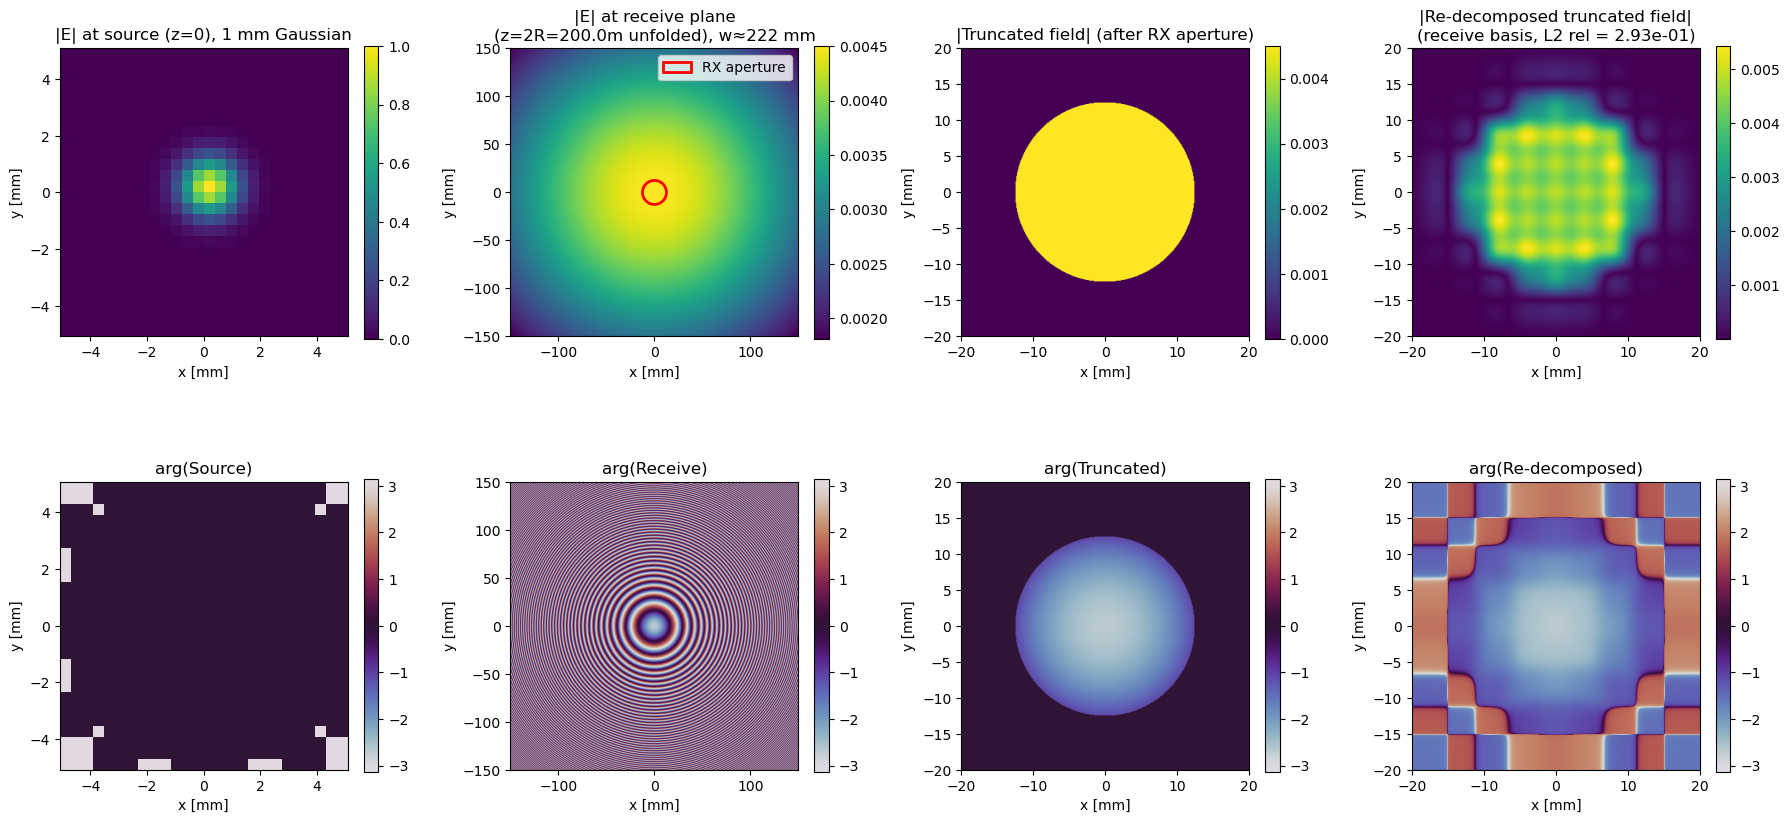

In [10]:
# Compute basis sum at source plane and receive plane on the FULL viz grid
t0 = time.time()
E_at_source_viz = basis_sum_at_z(basis_states_source, c_source, X, Y, k, z=0.0)
E_at_receive_viz = basis_sum_at_z(basis_states_postlens, c_source, X, Y, k, z=z_receive_unfolded)
print(f'Basis sums on viz grid took {time.time()-t0:.1f} s')

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Source plane (full grid, but crop to ±5mm for visibility)
ix_s = (np.argmin(np.abs(x + 5e-3)), np.argmin(np.abs(x - 5e-3)))
iy_s = (np.argmin(np.abs(y + 5e-3)), np.argmin(np.abs(y - 5e-3)))
ext_s = [x[ix_s[0]]*1e3, x[ix_s[1]]*1e3, y[iy_s[0]]*1e3, y[iy_s[1]]*1e3]
im = axes[0, 0].imshow(np.abs(E_at_source_viz[iy_s[0]:iy_s[1], ix_s[0]:ix_s[1]]), origin='lower', extent=ext_s, cmap='viridis')
axes[0, 0].set_title('|E| at source (z=0), 1 mm Gaussian')
axes[0, 0].set_xlabel('x [mm]'); axes[0, 0].set_ylabel('y [mm]')
plt.colorbar(im, ax=axes[0, 0], fraction=0.046)

# Receive plane (full grid, crop to ±150mm)
ix_r = (np.argmin(np.abs(x + 150e-3)), np.argmin(np.abs(x - 150e-3)))
iy_r = (np.argmin(np.abs(y + 150e-3)), np.argmin(np.abs(y - 150e-3)))
ext_r = [x[ix_r[0]]*1e3, x[ix_r[1]]*1e3, y[iy_r[0]]*1e3, y[iy_r[1]]*1e3]
im = axes[0, 1].imshow(np.abs(E_at_receive_viz[iy_r[0]:iy_r[1], ix_r[0]:ix_r[1]]), origin='lower', extent=ext_r, cmap='viridis')
axes[0, 1].set_title(f'|E| at receive plane\n(z=2R={z_receive_unfolded}m unfolded), w≈{w_at_receive*1e3:.0f} mm')
axes[0, 1].set_xlabel('x [mm]'); axes[0, 1].set_ylabel('y [mm]')
plt.colorbar(im, ax=axes[0, 1], fraction=0.046)
# overlay RX aperture circle
from matplotlib.patches import Circle
axes[0, 1].add_patch(Circle((0,0), D_RX/2*1e3, fill=False, color='red', lw=2, label='RX aperture'))
axes[0, 1].legend()

# Truncated field (LSQ grid)
ext_lsq = [-Lx_lsq*1e3, Lx_lsq*1e3, -Ly_lsq*1e3, Ly_lsq*1e3]
im = axes[0, 2].imshow(np.abs(E_truncated_lsq), origin='lower', extent=ext_lsq, cmap='viridis')
axes[0, 2].set_title('|Truncated field| (after RX aperture)')
axes[0, 2].set_xlabel('x [mm]'); axes[0, 2].set_ylabel('y [mm]')
plt.colorbar(im, ax=axes[0, 2], fraction=0.046)

# Re-decomposed reconstruction
im = axes[0, 3].imshow(np.abs(E_recon_receive), origin='lower', extent=ext_lsq, cmap='viridis')
axes[0, 3].set_title(f'|Re-decomposed truncated field|\n(receive basis, L2 rel = {L2_receive_floor:.2e})')
axes[0, 3].set_xlabel('x [mm]'); axes[0, 3].set_ylabel('y [mm]')
plt.colorbar(im, ax=axes[0, 3], fraction=0.046)

# Bottom row: phases
kz_at_receive = k
for col, (label, E, ext, kz_z) in enumerate([
    ('Source',           E_at_source_viz[iy_s[0]:iy_s[1], ix_s[0]:ix_s[1]], ext_s, 0),
    ('Receive',          E_at_receive_viz[iy_r[0]:iy_r[1], ix_r[0]:ix_r[1]], ext_r, kz_at_receive*z_receive_unfolded),
    ('Truncated',        E_truncated_lsq, ext_lsq, kz_at_receive*z_receive_unfolded),
    ('Re-decomposed',    E_recon_receive, ext_lsq, kz_at_receive*z_receive_unfolded),
]):
    E_env = E * np.exp(-1j*kz_z) if kz_z > 0 else E
    im = axes[1, col].imshow(np.angle(E_env), origin='lower', extent=ext, cmap='twilight', vmin=-np.pi, vmax=np.pi)
    axes[1, col].set_title(f'arg({label})')
    axes[1, col].set_xlabel('x [mm]'); axes[1, col].set_ylabel('y [mm]')
    plt.colorbar(im, ax=axes[1, col], fraction=0.046)

plt.tight_layout()
plt.show()

## Summary

If all sanity checks pass:
- **Sanity 1** (source decomposition): ~10⁻⁹, matching GBD_11 v2.
- **Sanity 2** (basis post-lens vs single-Gaussian post-lens): ~10⁻⁹, confirming per-beamlet lens math.
- **Sanity 3** (receive-basis decomposition of truncated field): ~10⁻³, the new and informative number.
- **Power budget** matches analytic prediction T = 1 − exp(−2·(D/2)²/w²) ≈ 0.64% for ρ=1.
- **Peak amplitude** at receive plane matches single-Gaussian prediction.

**What we demonstrated:**
- The full closed-loop LiDAR pipeline (source → lens → mirror → RX aperture) works in GBD with no AS-side validation needed (each component already validated separately).
- Two-basis design: source basis at TX plane, receive basis at receive plane. Each matched to its plane's beam size.
- Image method for round-trip propagation: planar mirror at normal incidence is equivalent to forward propagation by 2R. Conceptually simpler, mathematically identical.
- The decomposition error after a sharp aperture (~10⁻³) is the new "floor" downstream of the RX aperture — much higher than the pre-aperture decomposition floor (~10⁻⁹) because smooth Gaussians can't fit a sharp circular edge well.
- Power budget (~0.6% transmission) matches analytic prediction and matches typical FMCW LiDAR design numbers.

**What this notebook deliberately did NOT do** (saving for later):
- AS comparison. The chirp-aliasing limit from GBD_12 means AS isn't a clean reference for this chain. Plus, building blocks already validated.
- Receive optics (focusing lens to detector). The receive-basis output is ready for further per-beamlet lens application — but that's GBD_14 or a later notebook.
- Tilted/scanned beam (GBD_14).
- Non-Gaussian target (GBD_15+).
- Atmosphere (GBD_15+).
- Bistatic offset (TX/RX displaced transversely). Defer.

**Era 3 status after this notebook:** GBD_13 done (closed loop). One Phase 3A notebook remaining: **GBD_14 — scanner**, which adds tilt to the transmit beam by modifying `(kx, ky)` of every basis element.